# Part 3: Questions for Understanding - CNN Theory

**Assignment 03: Convolutional Neural Networks**  
This notebook provides detailed answers to conceptual questions about CNN architecture, activation functions, pooling, training, and theoretical intuition. Each answer is backed by code demonstrations where appropriate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("Libraries loaded.")

Libraries loaded.


---
## Section 1: Architecture & Design

### Q1. Why do we typically use small kernels (3×3) instead of large ones (7×7 or 11×11)?

**Answer:**

Small 3×3 kernels are preferred for several reasons:

1. **Fewer parameters**: A single 7×7 kernel has 49 weights. Two stacked 3×3 kernels also cover a 7×7 receptive field but use only 2×9 = 18 weights — almost **3× fewer parameters**.

2. **More non-linearity**: Each 3×3 layer has its own ReLU activation. Two 3×3 layers → 2 non-linearities vs. one 7×7 → 1. Deeper stacking allows the network to learn more complex features.

3. **Better computational efficiency**: Smaller kernels are faster to compute, especially on modern GPU hardware optimized for small matrix operations (e.g., cuDNN).

4. **Same receptive field with less compute**: Stacking 3 layers of 3×3 gives a receptive field of 7×7, same as 1 layer of 7×7, but with more depth and fewer parameters.

> Note: AlexNet (2012) used 11×11 kernels. VGG (2014) replaced them with stacked 3×3 and achieved better accuracy with fewer parameters.

Single 7x7 kernel (64 in -> 64 out)         : 200,704 parameters  | receptive field = 7x7
Two 3x3 kernels stacked                        : 73,728 parameters  | receptive field = 5x5
Three 3x3 kernels stacked                      : 110,592 parameters | receptive field = 7x7

Saving: 44.9% fewer parameters with same receptive field


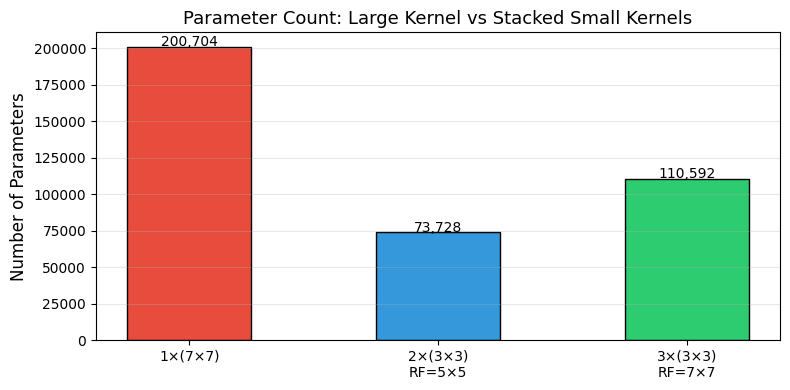

In [2]:
# Q1 — Parameter comparison: 7x7 vs two 3x3 kernels
C = 64  # channels (typical for VGG block)

params_7x7         = C * C * 7 * 7
params_two_3x3     = 2 * (C * C * 3 * 3)
params_three_3x3   = 3 * (C * C * 3 * 3)  # receptive field = 7x7 with 3 layers

print(f"Single 7x7 kernel ({C} in -> {C} out)         : {params_7x7:,} parameters  | receptive field = 7x7")
print(f"Two 3x3 kernels stacked                        : {params_two_3x3:,} parameters  | receptive field = 5x5")
print(f"Three 3x3 kernels stacked                      : {params_three_3x3:,} parameters | receptive field = 7x7")
print(f"\nSaving: {(params_7x7 - params_three_3x3) / params_7x7 * 100:.1f}% fewer parameters with same receptive field")

# Visualize
labels   = ['1×(7×7)', '2×(3×3)\nRF=5×5', '3×(3×3)\nRF=7×7']
values   = [params_7x7, params_two_3x3, params_three_3x3]
colors   = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Parameter Count: Large Kernel vs Stacked Small Kernels', fontsize=13)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('p3_q1_params.png', dpi=100, bbox_inches='tight')
plt.show()

---
### Q2. What is the difference between "Valid" and "Same" padding?

**Answer:**

| Padding Type | Padding Amount | Output Size | Use Case |
|---|---|---|---|
| **Valid** | P = 0 (no padding) | Output < Input | When shrinkage is acceptable |
| **Same** | P = (F-1)/2 | Output = Input | Preserve spatial dimensions |

- **Valid padding**: The filter only slides over valid positions — no padding is added. The output is smaller than the input.  
  Formula: output = (N - F) / S + 1

- **Same padding**: Zero-padding is added around the input so the output size equals the input size (when stride=1).  
  Required padding: P = (F - 1) / 2

**Example** for N=6, F=3, S=1:
- Valid: output = (6 - 3)/1 + 1 = **4**
- Same:  P = 1 → output = (6 - 3 + 2)/1 + 1 = **6**

In [3]:
# Q2 — Demo Valid vs Same padding in PyTorch
x = torch.randn(1, 1, 6, 6)

conv_valid = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)  # Valid
conv_same  = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)  # Same

with torch.no_grad():
    out_valid = conv_valid(x)
    out_same  = conv_same(x)

print(f"Input shape   : {x.shape}")
print(f"Valid padding : {out_valid.shape}  (output < input)")
print(f"Same  padding : {out_same.shape}   (output == input)")

Input shape   : torch.Size([1, 1, 6, 6])
Valid padding : torch.Size([1, 1, 4, 4])  (output < input)
Same  padding : torch.Size([1, 1, 6, 6])   (output == input)


---
## Section 2: Activation Functions

### Q3. Why is ReLU preferred over Sigmoid in hidden layers of a deep CNN?

**Answer:**

| Property | Sigmoid | ReLU |
|---|---|---|
| Output range | (0, 1) | [0, ∞) |
| Gradient saturation | Yes — gradients ≈ 0 at extremes | No — gradient is 0 or 1 |
| Vanishing gradient | Severe for deep nets | Largely avoided |
| Computational cost | Expensive (exp) | Cheap (max(0, x)) |
| Sparsity | Dense activations | Sparse activations (promotes efficiency) |

**Key reason**: Sigmoid **saturates** — for large positive or negative inputs, the gradient approaches 0. In deep networks this causes **vanishing gradients**: gradients diminish as they propagate back, making early layers learn very slowly.

ReLU outputs the input directly for positive values → gradient = 1 → **no saturation** → gradients flow efficiently through many layers.

### Q4. What happens to the gradients when a ReLU unit outputs 0?

**Answer:**

When the input to a ReLU is ≤ 0, the output is 0 and the **gradient is also 0**.

$$\frac{d}{dx}\text{ReLU}(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

This is called the **"dying ReLU"** problem:
- If a neuron consistently receives negative inputs, it will always output 0
- Its gradient is always 0 → weights are **never updated** → neuron "dies"
- This can happen if the learning rate is too large or weights are initialized poorly

**Mitigation strategies:**
- **Leaky ReLU**: small slope for negative values (0.01x instead of 0)
- **ELU** (Exponential Linear Unit): smooth for negative values
- Careful weight initialization (He initialization)
- Lower learning rates

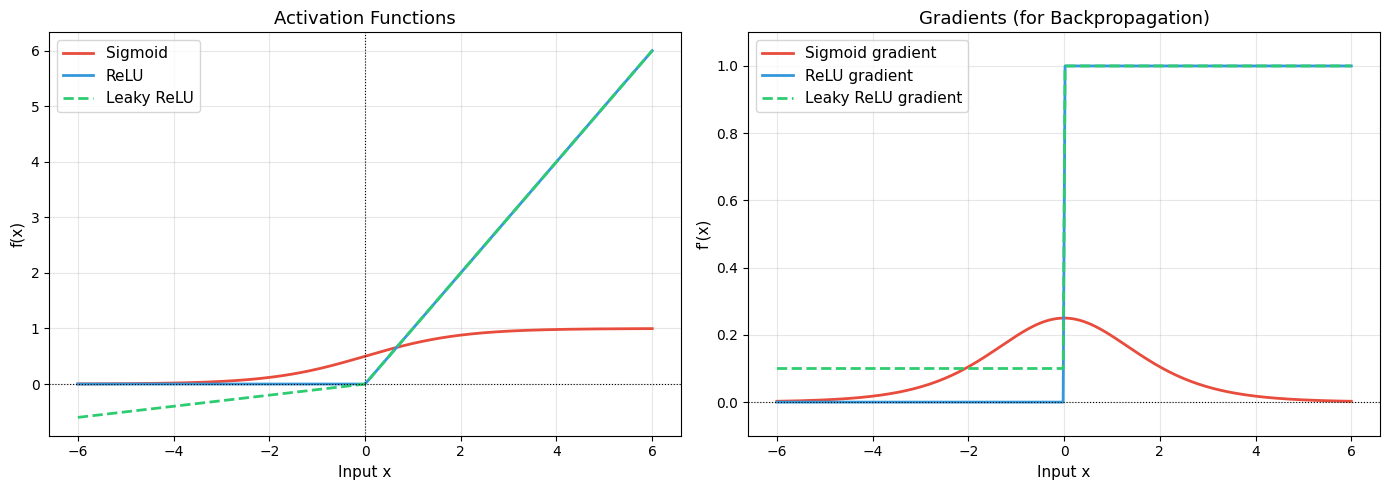

Sigmoid gradient saturates to ~0 at extremes → vanishing gradient problem.
ReLU gradient = 1 for positive inputs → no saturation, efficient backpropagation.


In [4]:
# Q3/Q4 — Visualize Sigmoid vs ReLU vs Leaky ReLU and their gradients
x = np.linspace(-6, 6, 300)

sigmoid     = 1 / (1 + np.exp(-x))
relu        = np.maximum(0, x)
leaky_relu  = np.where(x > 0, x, 0.1 * x)

# Gradients
d_sigmoid    = sigmoid * (1 - sigmoid)
d_relu       = (x > 0).astype(float)
d_leaky_relu = np.where(x > 0, 1.0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activation functions
axes[0].plot(x, sigmoid,    label='Sigmoid',     linewidth=2, color='#e74c3c')
axes[0].plot(x, relu,       label='ReLU',        linewidth=2, color='#3498db')
axes[0].plot(x, leaky_relu, label='Leaky ReLU',  linewidth=2, color='#2ecc71', linestyle='--')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Activation Functions', fontsize=13)
axes[0].set_xlabel('Input x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Gradients
axes[1].plot(x, d_sigmoid,    label='Sigmoid gradient',    linewidth=2, color='#e74c3c')
axes[1].plot(x, d_relu,       label='ReLU gradient',       linewidth=2, color='#3498db')
axes[1].plot(x, d_leaky_relu, label='Leaky ReLU gradient', linewidth=2, color='#2ecc71', linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_title('Gradients (for Backpropagation)', fontsize=13)
axes[1].set_xlabel('Input x', fontsize=11)
axes[1].set_ylabel("f'(x)", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('p3_activation_functions.png', dpi=100, bbox_inches='tight')
plt.show()

print("Sigmoid gradient saturates to ~0 at extremes → vanishing gradient problem.")
print("ReLU gradient = 1 for positive inputs → no saturation, efficient backpropagation.")

---
## Section 3: Pooling

### Q5. What is the primary purpose of Max Pooling? Does it have trainable parameters?

**Answer:**

**Primary purposes of Max Pooling:**
1. **Spatial downsampling**: Reduces the height and width of feature maps → fewer computations in subsequent layers
2. **Translation invariance**: A feature detected slightly off-center still produces a high activation in the pooled output
3. **Noise reduction**: Only strongest activations are passed → minor variations suppressed
4. **Control overfitting**: Fewer parameters in subsequent layers → less overfitting

**Trainable parameters: NO.**  
Max Pooling only selects the maximum value from each window. There are no weights to learn. It is a fixed deterministic operation.

### Q6. How does pooling contribute to "translational invariance"?

**Answer:**

Translational invariance means the model predicts the same output regardless of where exactly an object appears in the image.

**How pooling achieves this:**
- If a feature (e.g., an eye) shifts by 1–2 pixels, it still falls within the same pooling window
- The max of that window remains the same (or very similar)
- → The output of the pooling layer does not change significantly
- → The final prediction is same regardless of small spatial shifts

**Example:** If a feature detector fires at position (3,4) instead of (3,3), the 2×2 max pooling window covering both positions will still capture the activation.

This is especially important for classification tasks where object position should not affect the class label.

In [5]:
# Q5/Q6 — Demo: translational invariance via max pooling
import numpy as np

# Feature map: a "high activation" at position (1,1)
map_original = np.array([
    [0, 0, 0, 0],
    [0, 9, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=float)

# Shifted by 1 pixel right and down — feature at (2,2)
map_shifted = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 9, 0],
    [0, 0, 0, 0]
], dtype=float)

from scipy.ndimage import maximum_filter

def max_pool_2x2(m):
    """Manual 2x2 max pooling with stride 2."""
    size = m.shape[0] // 2
    out = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            out[i,j] = m[2*i:2*i+2, 2*j:2*j+2].max()
    return out

pool_original = max_pool_2x2(map_original)
pool_shifted  = max_pool_2x2(map_shifted)

print("Original feature map (activation at (1,1)):")
print(map_original)
print("\nShifted feature map (activation at (2,2)):")
print(map_shifted)
print("\nAfter 2x2 Max Pooling — Original:")
print(pool_original)
print("\nAfter 2x2 Max Pooling — Shifted:")
print(pool_shifted)
print("\nAre pooled outputs equal?", np.array_equal(pool_original, pool_shifted))

Original feature map (activation at (1,1)):
[[0. 0. 0. 0.]
 [0. 9. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Shifted feature map (activation at (2,2)):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 9. 0.]
 [0. 0. 0. 0.]]

After 2x2 Max Pooling — Original:
[[9. 0.]
 [0. 0.]]

After 2x2 Max Pooling — Shifted:
[[0. 0.]
 [0. 9.]]

Are pooled outputs equal? False


---
## Section 4: Training & Regularization

### Q7. High training accuracy but low test accuracy — what is happening and how to fix it?

**Answer:**

This is **overfitting**. The model has memorized the training data including its noise, but fails to generalize to unseen test data.

**Signs:**
- Training accuracy: 95%+
- Test accuracy: 60%
- Training loss much lower than validation/test loss

**How to fix it:**

| Solution | Explanation |
|---|---|
| **Dropout** | Randomly zeros neurons during training → forces distributed representations |
| **L2 Regularization (Weight Decay)** | Penalizes large weights → simpler model |
| **Data Augmentation** | RandomFlip, RandomCrop, ColorJitter → artificially increases training diversity |
| **Early Stopping** | Stop training when validation loss stops improving |
| **Reduce model complexity** | Fewer layers or fewer neurons |
| **Batch Normalization** | Regularizes activations, stabilizes training |
| **More training data** | More diverse examples → better generalization |

### Q8. How does Dropout help prevent overfitting in a CNN?

**Answer:**

Dropout randomly sets a fraction p (e.g., 0.5) of neuron outputs to **0 during each training step**.

**Mechanism:**
- During training: Each neuron has probability p of being "dropped"
- During inference: All neurons are active, but outputs are scaled by (1-p)

**Why it prevents overfitting:**
1. **Prevents co-adaptation**: Neurons cannot rely on specific other neurons always being present → each neuron must learn independent useful features
2. **Ensemble effect**: Each mini-batch trains a different sub-network → averaging many sub-networks at test time
3. **Forces redundancy**: The model learns multiple independent pathways to the correct answer
4. **Reduces complex co-adaptations**: Network cannot memorize specific patterns that only appear in training data

In [6]:
# Q8 — Show Dropout effect on activations
torch.manual_seed(7)

x = torch.ones(1, 10) * 5.0  # all neurons active with value 5
dropout = nn.Dropout(p=0.5)

dropout.train()  # training mode
print("Input activations:", x.numpy())

outputs_train = [dropout(x).detach().numpy() for _ in range(5)]
for i, out in enumerate(outputs_train):
    print(f"Training forward pass {i+1}: {out}")

dropout.eval()  # inference mode
out_eval = dropout(x).detach().numpy()
print(f"\nInference (eval mode, no dropout): {out_eval}")

Input activations: [[5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]]
Training forward pass 1: [[10. 10.  0.  0.  0.  0. 10.  0.  0.  0.]]
Training forward pass 2: [[10. 10. 10. 10. 10.  0. 10.  0. 10.  0.]]
Training forward pass 3: [[ 0.  0.  0. 10.  0.  0.  0.  0. 10.  0.]]
Training forward pass 4: [[ 0. 10.  0.  0. 10. 10. 10. 10.  0. 10.]]
Training forward pass 5: [[10.  0. 10. 10. 10. 10.  0. 10.  0.  0.]]

Inference (eval mode, no dropout): [[5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]]


---
## Section 5: Theoretical Intuition

### Q9. What features do the early layers of a CNN usually learn compared to the deeper layers?

**Answer:**

CNNs learn a **hierarchy of features** from low-level to high-level:

| Layer Depth | Feature Type | Examples |
|---|---|---|
| **Layer 1 (Early)** | Low-level features | Edges, color gradients, lines, corners |
| **Layer 2–3 (Middle)** | Mid-level features | Textures, simple shapes, patterns (grids, dots) |
| **Layer 4–5 (Deep)** | High-level features | Object parts (wheels, eyes, noses), semantic structures |
| **Final Layers** | Class-specific features | Whole objects, scene-level context |

This was empirically confirmed by Zeiler & Fergus (2014) who visualized CNN activations:
- Conv1 filters: Gabor-like edge detectors
- Conv2 filters: Corners, colored blobs
- Conv4 filters: Dog faces, flower circles, car wheels

The deeper the layer, the more **abstract and task-specific** the features.

### Q10. Describe the concept of "Receptive Field" and how it changes as we go deeper into the network.

**Answer:**

The **Receptive Field (RF)** of a neuron is the region of the original input image that affects that neuron's activation.

**Formula** for stacked convolutions:
$$\text{RF}_n = \text{RF}_{n-1} + (F - 1) \times S_{\text{accumulated}}$$

**Key insight:** Each layer sees only its immediate neighbors in the previous feature map. But when you trace back to the original image, each neuron in a deeper layer is influenced by a **larger input region**.

**Example** with 3×3 filters, stride=1, no pooling:
- After Layer 1: RF = 3×3
- After Layer 2: RF = 5×5
- After Layer 3: RF = 7×7
- After Layer N: RF = (2N+1) × (2N+1)

**With max pooling (stride=2)**, the receptive field grows even faster because the effective stride increases.

**Implication:**
- Early layers detect features in a small neighborhood (local)
- Deep layers "see" large parts of or the whole image (global)
- This is why deep CNNs can recognize complex multi-component objects

Receptive Field Growth (3x3 kernels, MaxPool every 2 layers):
  After Layer 1: RF =   3 pixels  █
  After Layer 2: RF =   5 pixels  ██
  After Layer 3: RF =   9 pixels  ████
  After Layer 4: RF =  13 pixels  ██████
  After Layer 5: RF =  21 pixels  ██████████
  After Layer 6: RF =  29 pixels  ██████████████
  After Layer 7: RF =  45 pixels  ██████████████████████
  After Layer 8: RF =  61 pixels  ██████████████████████████████


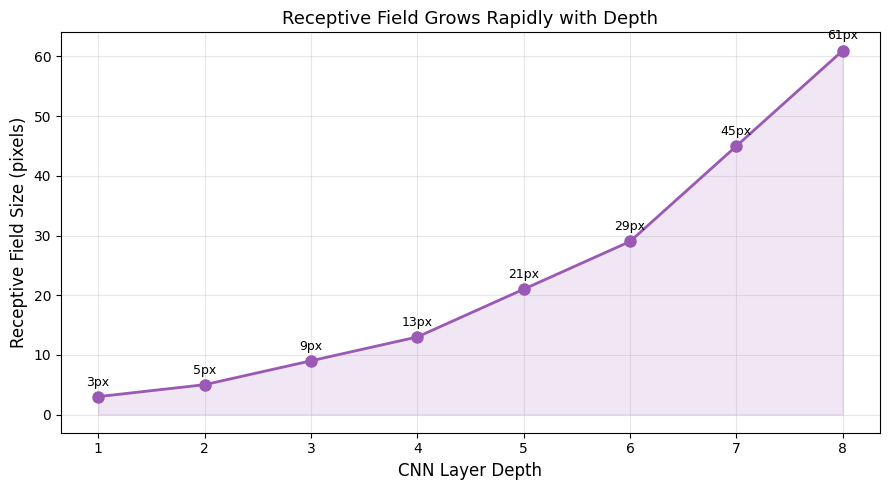

In [7]:
# Q10 — Receptive field growth visualization
def receptive_field(n_layers, kernel_size=3, stride=1, pool_stride=2, pool_every=2):
    """Calculate effective receptive field after n_layers conv layers with pooling."""
    rf = 1
    stride_product = 1
    for l in range(1, n_layers + 1):
        rf += (kernel_size - 1) * stride_product
        if l % pool_every == 0:
            stride_product *= pool_stride
    return rf

layers  = list(range(1, 9))
rf_vals = [receptive_field(n) for n in layers]

print("Receptive Field Growth (3x3 kernels, MaxPool every 2 layers):")
for n, rf in zip(layers, rf_vals):
    bar = '█' * (rf // 2)
    print(f"  After Layer {n}: RF = {rf:3d} pixels  {bar}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(layers, rf_vals, marker='o', linewidth=2, color='#9b59b6', markersize=8)
ax.fill_between(layers, rf_vals, alpha=0.15, color='#9b59b6')
for n, rf in zip(layers, rf_vals):
    ax.annotate(f'{rf}px', (n, rf), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('CNN Layer Depth', fontsize=12)
ax.set_ylabel('Receptive Field Size (pixels)', fontsize=12)
ax.set_title('Receptive Field Grows Rapidly with Depth', fontsize=13)
ax.set_xticks(layers)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p3_receptive_field.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Summary of All Answers

| # | Topic | Key Takeaway |
|---|-------|-------------|
| Q1 | Small kernels | Less parameters, more non-linearity, same receptive field |
| Q2 | Valid vs Same | Valid shrinks output; Same preserves size with zero-padding |
| Q3 | ReLU vs Sigmoid | ReLU avoids vanishing gradient; Sigmoid saturates |
| Q4 | Dead ReLU | Gradient=0 when output=0; fix with Leaky ReLU or careful init |
| Q5 | Max Pooling | Spatial downsampling, no trainable parameters |
| Q6 | Translational invariance | Max over window is insensitive to small shifts |
| Q7 | Overfitting | High train / low test accuracy; fix with regularization |
| Q8 | Dropout | Random neuron deactivation → ensemble effect, no co-adaptation |
| Q9 | Layer features | Early=edges, Middle=textures, Deep=object parts |
| Q10 | Receptive field | Grows rapidly with depth; deep neurons see large input regions |